In [1]:
%cd ..

/Users/n-zagainov/kolobok/ml


In [15]:
from pathlib import Path
import json
from typing import Optional, Callable, Tuple
import random
from functools import partial
from copy import deepcopy

import cv2
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.transforms import v2 as v2_transforms
from torchvision.transforms import functional as VF, InterpolationMode
from torchvision.io import read_image

from matplotlib import pyplot as plt
from tqdm import tqdm

from transformers import SegformerForSemanticSegmentation, SegformerConfig


In [3]:
data_train = Path("data/sidewall/train_processed")
data_val = Path("data/sidewall/val_processed")
backgrounds_root = Path("data/sidewall/backgrounds")

images_name = "images"
targets_name = "masks"
masks_name = "masks_v2"


In [4]:
def upscale_background(background, img):
    *_, h, w = img.shape
    background = VF.resize(
        background, (h * 3 // 2, w * 3 // 2), interpolation=InterpolationMode.BICUBIC
    )

    return background


def random_crop(background, img):
    *_, h, w = img.shape
    transform = transforms.RandomCrop(size=(h, w))
    crop = transform(background)

    return crop


def augment(background):
    transform = transforms.Compose(
        [
            transforms.ColorJitter(
                brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5
            ),
            transforms.RandAugment(num_ops=5),
        ]
    )
    background = transform(background)
    return background


def random_replace_background(img, background, mask, multiplier: float = 0.4):
    background = upscale_background(background, img)
    background = random_crop(background, img)
    background = augment(background)

    background = background / 255 * multiplier
    background = v2_transforms.GaussianNoise(0.2)(background)

    return ((img * mask + background * (1 - mask)) * 255).to(torch.uint8)

In [5]:
def augment_background(image, mask, background_paths, prob, multiplier):
    if random.random() > prob:
        return image, mask

    background_path = random.choice(background_paths)
    background = read_image(background_path)
    image = random_replace_background(image, background, mask, multiplier)

    return image, mask


class SidewallSegmentationDataset(Dataset):
    def __init__(self, data_root: Path, resize: Optional[Tuple[int, int]] = None, aug_fn: Optional[Callable] = None):
        self.image_paths = []
        images_root = data_root / "images"
        masks_root = data_root / "masks"
        self.resize = resize
        self.aug_fn = aug_fn

        for image_path in images_root.glob("*.png"):
            image_name = image_path.name
            mask_path = masks_root / image_name

            if not image_path.exists() or not mask_path.exists():
                continue

            self.image_paths.append((image_path, mask_path))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        image_path, mask_path = self.image_paths[idx]
        image = read_image(image_path) / 255
        mask = read_image(mask_path) / 255

        if self.aug_fn is not None:
            image, mask = self.aug_fn(image, mask)
        
        if self.resize is not None:
            image = VF.resize(image, self.resize, interpolation=InterpolationMode.BICUBIC)
            mask = VF.resize(mask, self.resize, interpolation=InterpolationMode.NEAREST)

        return image, mask

In [6]:

train_dataset = SidewallSegmentationDataset(
    data_root=data_train,
    resize=(512, 512),
    aug_fn=partial(
        augment_background,
        background_paths=list(backgrounds_root.glob("*.png")),
        prob=0.4,
        multiplier=0.35,
    ),
)
val_dataset = SidewallSegmentationDataset(
    data_root=data_val,
    resize=(512, 512),
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


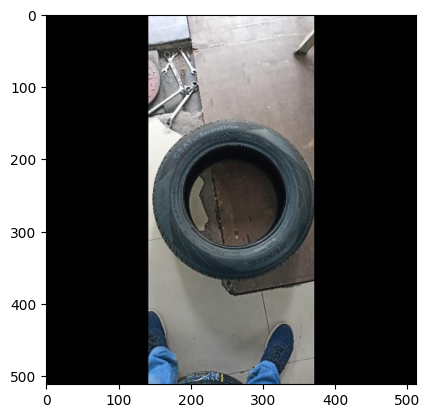

In [7]:
img, mask = val_dataset[3]
plt.imshow(img.permute(1, 2, 0))

In [8]:
class SegformerWrapper(nn.Module):
    def __init__(self, model: nn.Module):
        super().__init__()
        self.model = model

    def _upscale_logits(self, logits: torch.Tensor, target_shape: tuple = (512, 512)):
        logits = VF.resize(
            logits, 
            size=target_shape, 
            interpolation=InterpolationMode.BILINEAR,
        )
        return logits

    def forward(self, images: torch.Tensor):
        logits = self.model(images).logits
        # logits = self._upscale_logits(logits, target_shape=images.shape[2:])
        return logits

model_name = "nvidia/segformer-b2-finetuned-ade-512-512"


config = SegformerConfig.from_pretrained(model_name)
config.num_labels = 1  

base_model = SegformerForSemanticSegmentation.from_pretrained(
    model_name,
    config=config,
    ignore_mismatched_sizes=True,
    weights_only=False,
)

model = SegformerWrapper(base_model)

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([1, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
output = model(img[None])

In [10]:
output.shape

torch.Size([1, 1, 128, 128])

In [11]:
def binary_dice_loss(probs: torch.Tensor, labels: torch.Tensor, eps=1e-6):
    """
    logits: [B, C, H, W] raw scores
    labels: [B, H, W] ints in [0..C-1]
    """
    # convert to one-hot: [B, C, H, W]
    # compute per-class dice
    labels = labels.to(probs.dtype)
    intersection = torch.sum(probs * labels, dim=(1, 2))
    union = torch.sum(probs + labels, dim=(1, 2))
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


def binary_focal_loss(probs: torch.Tensor, labels: torch.Tensor, gamma: float = 2.0):
    """
    logits: [B, C, H, W] raw scores
    labels: [B, H, W] ints in [0..C-1]
    """
    return torch.mean(
        -(labels * torch.log(probs) * (1 - probs) ** gamma)
        - ((1 - labels) * torch.log(1 - probs) * (probs) ** gamma)
    )

def resize_target(logits: torch.Tensor, target: torch.Tensor):
    *_, h, w = logits.shape
    return VF.resize(target, (h, w), interpolation=InterpolationMode.NEAREST)


class BinarySegformerLoss(nn.Module):
    def __init__(self, focal_weight: float = 1, dice_weight: float = 1):
        super().__init__()
        self.focal_weight = focal_weight
        self.dice_weight = dice_weight

    def forward(self, logits: torch.Tensor, labels: torch.Tensor):
        labels = resize_target(logits, labels)
        probs = F.sigmoid(logits.squeeze(1))
        focal = binary_focal_loss(probs, labels)
        dice = binary_dice_loss(probs, labels)
        return self.focal_weight * focal + self.dice_weight * dice

def iou(logits: torch.Tensor, labels: torch.Tensor, threshold: float=0.5, eps: float = 1e-6) -> torch.Tensor:
    labels = resize_target(logits, labels)
    preds_bin = F.sigmoid(logits) > threshold
    labels_bin = labels > 0.5

    intersection = torch.sum(preds_bin & labels_bin, dim=(-2, -1)) + eps
    union = torch.sum(preds_bin | labels_bin, dim=(-2, -1)) + eps

    return intersection / union

In [12]:
def train_fn(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: str,
    n_epochs: int = 5,
):
    model.to(device)
    best_val_metric = -torch.inf
    best_model = deepcopy(model).cpu()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

    loss_fn = BinarySegformerLoss()

    for epoch in range(1, n_epochs + 1):
        model.train()
        running_loss = 0
        train_loop = tqdm(train_loader, desc=f"[{epoch}/{n_epochs}] Train Epoch")

        for i, (x, y) in enumerate(train_loop):
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            preds_raw = model(x)
            loss = loss_fn(preds_raw, y)
            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()

            train_loop.set_postfix(loss=running_loss / (i + 1))

        model.eval()
        ious = []
        eval_loop = tqdm(val_loader, desc=f"[{epoch}/{n_epochs}] Evaluation Epoch")

        with torch.no_grad():
            for i, (x, y) in enumerate(eval_loop):
                x = x.to(device)
                y = y.to(device)

                preds_raw = model(x).squeeze(1)
                ious.extend(iou(preds_raw, y).cpu().tolist())

                eval_loop.set_postfix(iou=np.mean(ious), best_iou=best_val_metric)

        val_metric = np.mean(ious)

        if val_metric > best_val_metric:
            best_val_metric = val_metric
            best_model = deepcopy(model).cpu()

    return best_model, val_metric


In [17]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [18]:
train_fn(model, train_loader, val_loader, "mps")

[1/5] Train Epoch:   0%|          | 0/38 [00:07<?, ?it/s]


RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.